# FFT-Driven Droplet Tracking Pipeline

This notebook explores a purely frequency-domain approach to droplet detection and tracking. Instead of running a trained neural detector, we enhance each video frame with FFT-based filters, detect salient frequency peaks, reconstruct spatial response maps, and then track the recovered droplet centroids with a Kalman filter plus Hungarian assignment.

Found 3365 frames in ../DATA/2.2/
Frame dimensions: 540x540


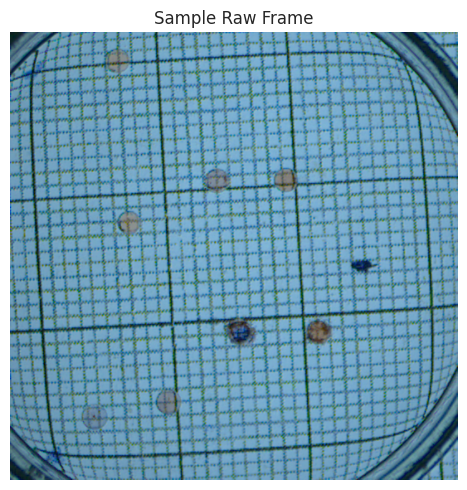

In [22]:
# ============================================================================
# SECTION 1: Configure Frame IO and FFT Parameters
# ============================================================================
import os
import glob
from typing import List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use("seaborn-v0_8")

# Paths and parameters
FRAME_FOLDER = "../DATA/2.2/"
OUTPUT_FOLDER = "output_fft_tracking"
CSV_OUTPUT = "fft_tracking_results.csv"
VIDEO_OUTPUT = "fft_tracking_visualization.mp4"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# FFT configuration
FFT_WINDOW_SIZE = 256  # tapered window applied before FFT
HIGHPASS_RADIUS = 18    # pixels removed around DC component
PEAK_PERCENTILE = 99.4   # percentile of spectrum retained as candidate peaks
PEAK_MIN_DISTANCE = 18   # enforce spacing between selected frequency peaks
PEAK_LOCAL_WINDOW = 9    # neighbourhood for local-maximum filtering
MAX_FREQ_PEAKS = 60

# Spatial detection parameters
RESPONSE_THRESHOLD = 0.25  # fraction of 0-1 normalized response map
MIN_DETECTION_AREA = 3      # pixels
MAX_DETECTION_AREA = 600

# Load frames
frame_paths = sorted(glob.glob(os.path.join(FRAME_FOLDER, "*.png")))
if not frame_paths:
    frame_paths = sorted(glob.glob(os.path.join(FRAME_FOLDER, "*.jpg")))

print(f"Found {len(frame_paths)} frames in {FRAME_FOLDER}")
if frame_paths:
    sample_frame = cv2.imread(frame_paths[0])
    if sample_frame is None:
        raise RuntimeError("Failed to read the first frame; please verify the path.")
    h, w = sample_frame.shape[:2]
    print(f"Frame dimensions: {w}x{h}")

    plt.figure(figsize=(6, 5))
    plt.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
    plt.title("Sample Raw Frame")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    raise FileNotFoundError("No frames detected in the provided folder.")


In [23]:
# ============================================================================
# SECTION 2: Implement FFT-Based Droplet Detector
# ============================================================================
from scipy import ndimage

if hasattr(signal, "windows") and hasattr(signal.windows, "tukey"):
    def _tukey(length: int, alpha: float) -> np.ndarray:
        return signal.windows.tukey(length, alpha=alpha)
elif hasattr(signal, "tukey"):
    def _tukey(length: int, alpha: float) -> np.ndarray:
        return signal.tukey(length, alpha=alpha)
else:
    def _tukey(length: int, alpha: float) -> np.ndarray:
        # Fallback to Hann window if Tukey is unavailable
        return np.hanning(length)


def to_grayscale(frame: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return gray.astype(np.float32)


def build_taper_window(shape: Tuple[int, int], window_size: int = FFT_WINDOW_SIZE) -> np.ndarray:
    rows, cols = shape
    wy = _tukey(rows, alpha=min(1.0, window_size / rows))
    wx = _tukey(cols, alpha=min(1.0, window_size / cols))
    window = np.outer(wy, wx)
    return window.astype(np.float32)


def compute_fft(gray: np.ndarray, window: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    tapered = gray * window
    fft2 = np.fft.fft2(tapered)
    fft_shifted = np.fft.fftshift(fft2)
    magnitude = np.log1p(np.abs(fft_shifted))  # S(u,v) = log(1 + |F(u,v)|)
    return fft_shifted, magnitude


def apply_band_pass(fft_shifted: np.ndarray, radius: int = HIGHPASS_RADIUS) -> np.ndarray:
    rows, cols = fft_shifted.shape
    mask = np.ones((rows, cols), dtype=np.float32)
    cy, cx = rows // 2, cols // 2
    mask[cy - radius:cy + radius, cx - radius:cx + radius] = 0.0
    filtered = fft_shifted * mask
    return filtered


def normalize_spectrum(spectrum: np.ndarray) -> np.ndarray:
    norm = cv2.normalize(spectrum, None, 0, 1, cv2.NORM_MINMAX)
    return norm.astype(np.float32)


# Pre-compute taper window for frame dimensions
taper_window = build_taper_window(sample_frame.shape[:2])
print("Prepared taper window for FFT preprocessing.")


Prepared taper window for FFT preprocessing.


In [24]:
# ============================================================================
# SECTION 3: Detect Peaks in Frequency Domain
# ============================================================================
from dataclasses import dataclass

@dataclass
class FrequencyPeak:
    row: int
    col: int
    prominence: float
    magnitude: float


def detect_frequency_peaks(
    magnitude: np.ndarray,
    intensity_percentile: float = PEAK_PERCENTILE,
    min_distance: int = PEAK_MIN_DISTANCE,
    max_peaks: int = MAX_FREQ_PEAKS,
    local_window: int = PEAK_LOCAL_WINDOW,
) -> List[FrequencyPeak]:
    if magnitude.size == 0:
        return []
    mag = magnitude.astype(np.float32)
    mag_smooth = cv2.GaussianBlur(mag, (5, 5), 0)
    local_window = int(max(3, local_window | 1))

    coords = []
    percentile = intensity_percentile
    while percentile >= 85 and len(coords) == 0:
        threshold = np.percentile(mag_smooth, percentile)
        local_max = mag_smooth == ndimage.maximum_filter(mag_smooth, size=local_window, mode="nearest")
        coords = np.argwhere(local_max & (mag_smooth >= threshold))
        if len(coords) == 0:
            percentile -= 1.5

    if len(coords) == 0:
        return []

    scores = mag_smooth[coords[:, 0], coords[:, 1]]
    order = np.argsort(scores)[::-1]

    selected: List[FrequencyPeak] = []
    for idx in order:
        row, col = coords[idx]
        if any(np.hypot(row - p.row, col - p.col) < min_distance for p in selected):
            continue
        selected.append(
            FrequencyPeak(
                row=int(row),
                col=int(col),
                prominence=float(scores[idx]),
                magnitude=float(magnitude[row, col]),
            )
        )
        if len(selected) >= max_peaks:
            break
    return selected


def visualize_spectrum_with_peaks(magnitude: np.ndarray, peaks: List[FrequencyPeak]):
    plt.figure(figsize=(6, 5))
    plt.imshow(magnitude, cmap="inferno")
    plt.colorbar(label="log-magnitude")
    plt.title("FFT Magnitude Spectrum + Peaks")
    for p in peaks:
        plt.scatter(p.col, p.row, s=30, edgecolors="white", facecolors="none")
    plt.tight_layout()
    plt.show()


In [25]:
# ============================================================================
# SECTION 4: Map Frequency Peaks to Spatial Detections
# ============================================================================

def build_peak_mask(shape: Tuple[int, int], peaks: List[FrequencyPeak], band: int = 6) -> np.ndarray:
    rows, cols = shape
    mask = np.zeros((rows, cols), dtype=np.float32)
    for p in peaks:
        r0, c0 = p.row, p.col
        r1, r2 = max(0, r0 - band), min(rows, r0 + band + 1)
        c1, c2 = max(0, c0 - band), min(cols, c0 + band + 1)
        mask[r1:r2, c1:c2] = 1.0
        # include conjugate symmetric partner
        partner_r = rows - r0 - 1
        partner_c = cols - c0 - 1
        r1, r2 = max(0, partner_r - band), min(rows, partner_r + band + 1)
        c1, c2 = max(0, partner_c - band), min(cols, partner_c + band + 1)
        mask[r1:r2, c1:c2] = 1.0
    return mask


def reconstruct_spatial_response(
    fft_shifted: np.ndarray,
    peaks: List[FrequencyPeak],
    band: int = 6,
) -> np.ndarray:
    if not peaks:
        return np.zeros_like(np.abs(fft_shifted), dtype=np.float32)
    mask = build_peak_mask(fft_shifted.shape, peaks, band)
    filtered_shift = fft_shifted * mask
    inv = np.fft.ifft2(np.fft.ifftshift(filtered_shift))
    response = np.abs(inv)
    response_norm = cv2.normalize(response, None, 0, 1, cv2.NORM_MINMAX)
    return response_norm.astype(np.float32)


def extract_spatial_detections(
    response_map: np.ndarray,
    threshold: float = RESPONSE_THRESHOLD,
    min_area: int = MIN_DETECTION_AREA,
    max_area: int = MAX_DETECTION_AREA,
) -> Tuple[np.ndarray, List[float]]:
    if response_map.max() <= 0:
        return np.empty((0, 2)), []
    response_uint8 = (response_map * 255).astype(np.uint8)
    _, binary = cv2.threshold(
        response_uint8,
        int(threshold * 255),
        255,
        cv2.THRESH_BINARY,
    )
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    detections: List[List[float]] = []
    confidences: List[float] = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area or area > max_area:
            continue
        cx, cy = centroids[i]
        detections.append([cx, cy])
        confidences.append(float(response_map[int(round(cy)), int(round(cx))]))
    return (np.array(detections, dtype=float) if detections else np.empty((0, 2))), confidences


In [26]:
# ============================================================================
# SECTION 5: Track Detections with Kalman + Hungarian Assignment
# ============================================================================
from dataclasses import dataclass
from scipy.optimize import linear_sum_assignment

@dataclass
class TrackRecord:
    frame: int
    track_id: int
    x: float
    y: float
    vx: float
    vy: float
    speed: float
    spectral_score: float


class KalmanTracker:
    def __init__(self, x: float, y: float, track_id: int):
        self.id = track_id
        self.state = np.array([x, y, 0.0, 0.0], dtype=float)
        self.P = np.eye(4) * 50.0
        self.F = np.array(
            [
                [1, 0, 1, 0],
                [0, 1, 0, 1],
                [0, 0, 1, 0],
                [0, 0, 0, 1],
            ],
            dtype=float,
        )
        self.H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], dtype=float)
        self.R = np.eye(2) * 4.0
        self.Q = np.eye(4) * 0.5
        self.missed_frames = 0

    def predict(self):
        self.state = self.F @ self.state
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.state[:2]

    def update(self, measurement: np.ndarray):
        z = measurement.astype(float)
        y = z - self.H @ self.state
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.state = self.state + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P
        self.missed_frames = 0

    def get_position(self):
        return self.state[:2]

    def get_velocity(self):
        return self.state[2:]


class TrackerManager:
    def __init__(self, max_distance: float = 25.0, max_missed_frames: int = 30):
        self.trackers: List[KalmanTracker] = []
        self.max_distance = max_distance
        self.max_missed_frames = max_missed_frames
        self.next_id = 0

    def update(self, detections: np.ndarray):
        if len(self.trackers) == 0:
            for det in detections:
                self.trackers.append(KalmanTracker(det[0], det[1], self.next_id))
                self.next_id += 1
            return

        predictions = np.array([trk.predict() for trk in self.trackers])
        if detections.size == 0:
            for trk in self.trackers:
                trk.missed_frames += 1
            self._prune_trackers()
            return

        cost = np.linalg.norm(predictions[:, None, :] - detections[None, :, :], axis=2)
        row_ind, col_ind = linear_sum_assignment(cost)

        assigned = set()
        used_detections = set()
        for r, c in zip(row_ind, col_ind):
            if cost[r, c] > self.max_distance:
                continue
            self.trackers[r].update(detections[c])
            assigned.add(r)
            used_detections.add(c)

        for idx, trk in enumerate(self.trackers):
            if idx not in assigned:
                trk.missed_frames += 1

        for det_idx, det in enumerate(detections):
            if det_idx not in used_detections:
                self.trackers.append(KalmanTracker(det[0], det[1], self.next_id))
                self.next_id += 1

        self._prune_trackers()

    def _prune_trackers(self):
        self.trackers = [t for t in self.trackers if t.missed_frames < self.max_missed_frames]

    def get_active(self) -> List[KalmanTracker]:
        return self.trackers.copy()


tracker = TrackerManager()
track_history: List[TrackRecord] = []
spectral_metrics: List[dict] = []

print("Beginning FFT-based detection + tracking loop...")
for frame_idx, img_path in enumerate(frame_paths):
    frame = cv2.imread(img_path)
    if frame is None:
        continue
    gray = to_grayscale(frame)
    fft_shifted, magnitude = compute_fft(gray, taper_window)
    filtered_fft = apply_band_pass(fft_shifted, HIGHPASS_RADIUS)
    magnitude_filtered = np.log1p(np.abs(filtered_fft))

    peaks = detect_frequency_peaks(
        magnitude_filtered,
        intensity_percentile=PEAK_PERCENTILE,
        min_distance=PEAK_MIN_DISTANCE,
        max_peaks=MAX_FREQ_PEAKS,
        local_window=PEAK_LOCAL_WINDOW,
    )

    mag_norm = normalize_spectrum(magnitude_filtered)
    response_map = reconstruct_spatial_response(filtered_fft, peaks)
    detections, confidences = extract_spatial_detections(response_map)

    tracker.update(detections)

    active = tracker.get_active()
    for trk in active:
        pos = trk.get_position()
        vel = trk.get_velocity()
        spectral_score = float(np.mean(confidences)) if confidences else 0.0
        track_history.append(
            TrackRecord(
                frame=frame_idx,
                track_id=trk.id,
                x=float(pos[0]),
                y=float(pos[1]),
                vx=float(vel[0]),
                vy=float(vel[1]),
                speed=float(np.linalg.norm(vel)),
                spectral_score=spectral_score,
            )
        )

    spectral_metrics.append(
        {
            "frame": frame_idx,
            "mean_spectral_energy": float(np.mean(mag_norm)),
            "peak_count": len(peaks),
            "mean_peak_mag": float(np.mean([p.magnitude for p in peaks])) if peaks else 0.0,
        }
    )

    if (frame_idx + 1) % max(1, len(frame_paths) // 10) == 0:
        print(f"Processed {frame_idx + 1}/{len(frame_paths)} frames")

tracks_df = pd.DataFrame([t.__dict__ for t in track_history])
spectral_df = pd.DataFrame(spectral_metrics)
print("Tracking complete. Records collected:", len(tracks_df))


Beginning FFT-based detection + tracking loop...
Processed 336/3365 frames
Processed 672/3365 frames
Processed 1008/3365 frames
Processed 1344/3365 frames
Processed 1680/3365 frames
Processed 2016/3365 frames
Processed 2352/3365 frames
Processed 2688/3365 frames
Processed 3024/3365 frames
Processed 3360/3365 frames
Tracking complete. Records collected: 7000933


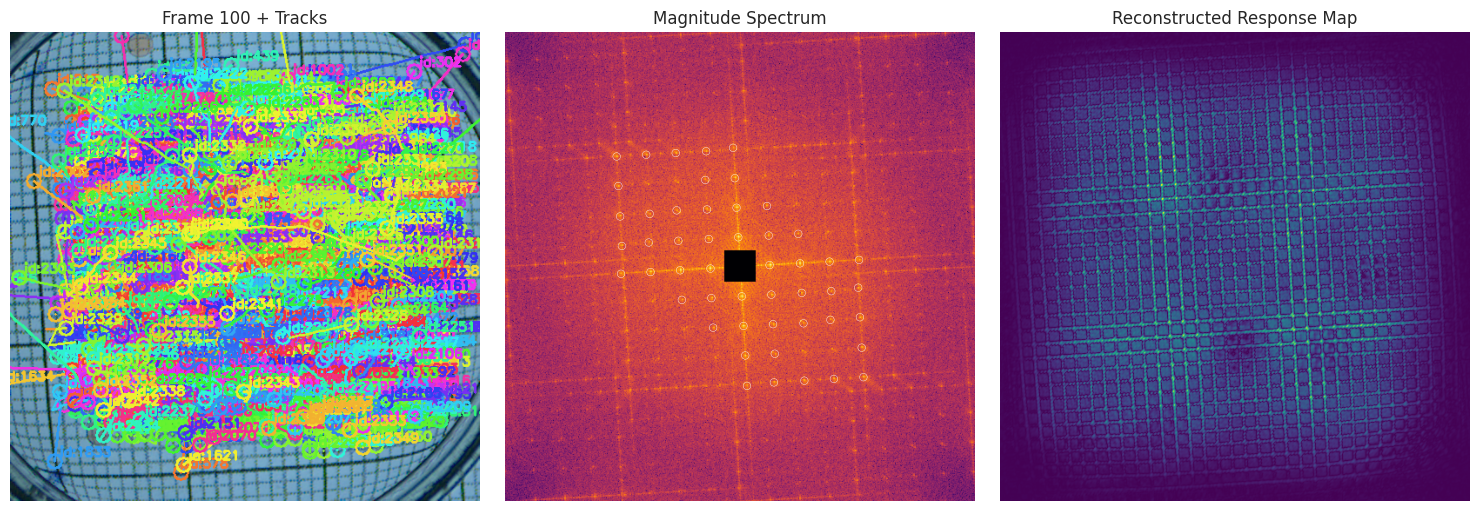

In [27]:
# ============================================================================
# SECTION 6: Visualize Trajectories and Spectral Diagnostics
# ============================================================================
from colorsys import hsv_to_rgb

def get_track_color(track_id: int) -> Tuple[int, int, int]:
    base = hash(track_id) % 360
    hue = (base % 360) / 360.0
    r, g, b = hsv_to_rgb(hue, 0.8, 0.95)
    return int(r * 255), int(g * 255), int(b * 255)

if not tracks_df.empty:
    PATH_WINDOW = 25
    frame_history = tracks_df.groupby("track_id")

    sample_idx = min(100, len(frame_paths) - 1)
    frame = cv2.imread(frame_paths[sample_idx])
    gray = to_grayscale(frame)
    fft_shifted, magnitude = compute_fft(gray, taper_window)
    filtered_fft = apply_band_pass(fft_shifted, HIGHPASS_RADIUS)
    magnitude_filtered = np.log1p(np.abs(filtered_fft))
    peaks = detect_frequency_peaks(magnitude_filtered)
    mag_norm = normalize_spectrum(magnitude_filtered)
    response_map = reconstruct_spatial_response(filtered_fft, peaks)

    overlay = frame.copy()
    sample_tracks = tracks_df[tracks_df["frame"] == sample_idx]
    for _, track in sample_tracks.iterrows():
        tid = int(track["track_id"])
        color = get_track_color(tid)
        cx, cy = int(track["x"]), int(track["y"])
        path = frame_history.get_group(tid)
        history = path[path["frame"] <= sample_idx].tail(PATH_WINDOW)
        if len(history) > 1:
            pts = history[["x", "y"]].to_numpy().astype(int)
            cv2.polylines(overlay, [pts], False, color, 2)
        cv2.circle(overlay, (cx, cy), 8, color, 2)
        cv2.putText(overlay, f"id:{tid}", (cx + 6, cy - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Frame {sample_idx} + Tracks")
    axes[0].axis("off")

    axes[1].imshow(mag_norm, cmap="inferno")
    axes[1].set_title("Magnitude Spectrum")
    for p in peaks:
        axes[1].scatter(p.col, p.row, s=30, edgecolors="white", facecolors="none")
    axes[1].axis("off")

    axes[2].imshow(response_map, cmap="viridis")
    axes[2].set_title("Reconstructed Response Map")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No tracking results to visualize yet.")


In [ ]:
# ============================================================================
# SECTION 7: Compute Frequency-Domain Metrics and Export
# ============================================================================
if not tracks_df.empty:
    csv_path = os.path.join(OUTPUT_FOLDER, CSV_OUTPUT)
    tracks_df.to_csv(csv_path, index=False)
    spectral_csv = os.path.join(OUTPUT_FOLDER, "spectral_metrics.csv")
    spectral_df.to_csv(spectral_csv, index=False)
    print(f"Saved tracking records to {csv_path}")
    print(f"Saved spectral diagnostics to {spectral_csv}")

    print("\nTracking summary:")
    print(tracks_df.describe()[["x", "y", "speed", "spectral_score"]])
    print("\nSpectral summary:")
    print(spectral_df.describe()[["mean_spectral_energy", "peak_count", "mean_peak_mag"]])

    # Optional visualization video
    output_video = os.path.join(OUTPUT_FOLDER, VIDEO_OUTPUT)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video, fourcc, 12, (sample_frame.shape[1], sample_frame.shape[0]))
    path_window = 25
    grouped = tracks_df.groupby("track_id")

    for frame_idx, img_path in enumerate(frame_paths):
        frame = cv2.imread(img_path)
        if frame is None:
            continue
        tracks_now = tracks_df[tracks_df["frame"] == frame_idx]
        for _, row in tracks_now.iterrows():
            tid = int(row["track_id"])
            color = get_track_color(tid)
            cx, cy = int(row["x"]), int(row["y"])
            history = grouped.get_group(tid)
            recent = history[history["frame"] <= frame_idx].tail(path_window)
            if len(recent) > 1:
                pts = recent[["x", "y"]].to_numpy().astype(int)
                cv2.polylines(frame, [pts], False, color, 2)
            cv2.circle(frame, (cx, cy), 6, color, 2)
            cv2.putText(frame, f"id:{tid}", (cx + 5, cy - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        writer.write(frame)
    writer.release()
    print(f"Visualization video exported to {output_video}")
else:
    print("No detections tracked; skipping export.")


Saved tracking records to output_fft_tracking/fft_tracking_results.csv
Saved spectral diagnostics to output_fft_tracking/spectral_metrics.csv

Tracking summary:
                  x             y         speed  spectral_score
count  7.000933e+06  7.000933e+06  7.000933e+06    7.000933e+06
mean   2.630865e+02  2.601835e+02  6.312186e-01    3.279202e-01
std    1.169789e+02  1.151356e+02  1.420770e+00    4.239384e-03
min   -6.089059e+02 -5.567953e+02  0.000000e+00    3.177500e-01
25%    1.564991e+02  1.595356e+02  5.242905e-03    3.251749e-01
50%    2.622417e+02  2.573817e+02  4.402991e-02    3.275474e-01
75%    3.691339e+02  3.620000e+02  4.128889e-01    3.307029e-01
max    1.004486e+03  9.977395e+02  2.739551e+01    3.400625e-01

Spectral summary:
       mean_spectral_energy   peak_count  mean_peak_mag
count           3365.000000  3365.000000    3365.000000
mean               0.498212    49.083804      11.951178
std                0.001430     2.592427       0.050133
min                0